In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 50

In [4]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [5]:
dataset = datasets.ImageFolder(
    root="Spiral_HandPD",
    transform=transform
)

In [6]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

In [7]:
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [8]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

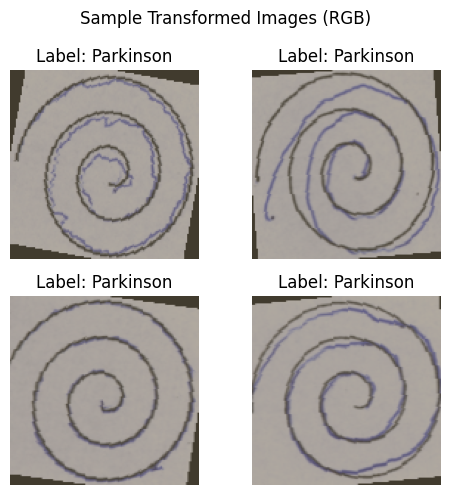

In [9]:
import matplotlib.pyplot as plt
import numpy as np

sample_batch = next(iter(train_loader))
images, labels = sample_batch

fig, axes = plt.subplots(2, 2, figsize=(5, 5))
fig.suptitle('Sample Transformed Images (RGB)')

for i, ax in enumerate(axes.flat):
    img = images[i].cpu()
    img = img.permute(1, 2, 0)

    img = img.numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    label_text = "Parkinson" if labels[i].item() == 1 else "Healthy"
    ax.set_title(f"Label: {label_text}")
    ax.axis('off')

plt.tight_layout()
plt.show()


In [10]:
class ParkinsonCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
model = ParkinsonCNN().to(DEVICE)

In [12]:
from torchinfo import summary

summary(model)

Layer (type:depth-idx)                   Param #
ParkinsonCNN                             --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       896
│    └─BatchNorm2d: 2-2                  64
│    └─ReLU: 2-3                         --
│    └─MaxPool2d: 2-4                    --
│    └─Conv2d: 2-5                       18,496
│    └─BatchNorm2d: 2-6                  128
│    └─ReLU: 2-7                         --
│    └─MaxPool2d: 2-8                    --
│    └─Conv2d: 2-9                       73,856
│    └─BatchNorm2d: 2-10                 256
│    └─ReLU: 2-11                        --
│    └─MaxPool2d: 2-12                   --
├─Sequential: 1-2                        --
│    └─Flatten: 2-13                     --
│    └─Linear: 2-14                      8,388,864
│    └─BatchNorm1d: 2-15                 512
│    └─ReLU: 2-16                        --
│    └─Dropout: 2-17                     --
│    └─Linear: 2-18                      257
Total p

In [13]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

In [14]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.float().to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [15]:

def validate_epoch(model, loader):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.float().to(DEVICE).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            preds = (torch.sigmoid(outputs) > 0.5).int().squeeze()
            correct += (preds == labels.squeeze()).sum().item()
            total += labels.size(0)
            
    return correct / total, total_loss / len(loader)

In [16]:
best_val_loss = float('inf')
patience = 10
patience_counter = 0
cnn_train_losses = []
cnn_val_losses = []
cnn_val_accs = []

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader)
    val_acc, val_loss = validate_epoch(model, val_loader)
    
    cnn_train_losses.append(train_loss)
    cnn_val_losses.append(val_loss)
    cnn_val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_acc:.4f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            model.load_state_dict(best_model_state)
            break

Epoch [1/50] Train Loss: 0.6984 Val Loss: 0.7606 Val Acc: 0.5135
Epoch [2/50] Train Loss: 0.4187 Val Loss: 0.5158 Val Acc: 0.7838
Epoch [3/50] Train Loss: 0.3657 Val Loss: 0.3843 Val Acc: 0.8784
Epoch [4/50] Train Loss: 0.3251 Val Loss: 0.3439 Val Acc: 0.8378
Epoch [5/50] Train Loss: 0.2444 Val Loss: 0.3463 Val Acc: 0.8378
Epoch [6/50] Train Loss: 0.2359 Val Loss: 0.3522 Val Acc: 0.8649
Epoch [7/50] Train Loss: 0.1931 Val Loss: 0.4995 Val Acc: 0.8378
Epoch [8/50] Train Loss: 0.1989 Val Loss: 0.2885 Val Acc: 0.8649
Epoch [9/50] Train Loss: 0.1920 Val Loss: 0.3490 Val Acc: 0.8378
Epoch [10/50] Train Loss: 0.1781 Val Loss: 0.3804 Val Acc: 0.8514
Epoch [11/50] Train Loss: 0.1760 Val Loss: 0.2224 Val Acc: 0.9189
Epoch [12/50] Train Loss: 0.1875 Val Loss: 0.4206 Val Acc: 0.8108
Epoch [13/50] Train Loss: 0.1428 Val Loss: 0.9267 Val Acc: 0.7838
Epoch [14/50] Train Loss: 0.1524 Val Loss: 0.2704 Val Acc: 0.9054
Epoch [15/50] Train Loss: 0.1575 Val Loss: 0.3499 Val Acc: 0.7703
Epoch [16/50] Train

In [17]:
from PIL import Image

def predict(image_path, model):
    model.eval()

    image = Image.open(image_path)
    image = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = torch.sigmoid(model(image))

    return output.item()

In [18]:
risk = predict("Parkinson.jpg", model)
print(f"Parkinson Risk Probability: {risk:.2f}")

Parkinson Risk Probability: 1.00


In [19]:
class ParkinsonMLP(nn.Module):
    def __init__(self, img_size=IMG_SIZE):
        super().__init__()

        input_dim = 3 * img_size * img_size

        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.model(x)

In [20]:
mlp_model = ParkinsonMLP(img_size=IMG_SIZE).to(DEVICE)

mlp_criterion = nn.BCEWithLogitsLoss()
mlp_optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

In [21]:
from torchinfo import summary

summary(mlp_model)

Layer (type:depth-idx)                   Param #
ParkinsonMLP                             --
├─Sequential: 1-1                        --
│    └─Flatten: 2-1                      --
│    └─Linear: 2-2                       50,332,672
│    └─BatchNorm1d: 2-3                  2,048
│    └─ReLU: 2-4                         --
│    └─Dropout: 2-5                      --
│    └─Linear: 2-6                       524,800
│    └─BatchNorm1d: 2-7                  1,024
│    └─ReLU: 2-8                         --
│    └─Dropout: 2-9                      --
│    └─Linear: 2-10                      131,328
│    └─BatchNorm1d: 2-11                 512
│    └─ReLU: 2-12                        --
│    └─Dropout: 2-13                     --
│    └─Linear: 2-14                      257
Total params: 50,992,641
Trainable params: 50,992,641
Non-trainable params: 0

In [22]:
def train_epoch_mlp(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.float().to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [23]:
def validate_epoch_mlp(model, loader, criterion):
    model.eval()
    correct, total = 0, 0
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.float().to(DEVICE).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).int().squeeze()
            correct += (preds == labels.squeeze()).sum().item()
            total += labels.size(0)

    return correct / total, total_loss / len(loader)

In [24]:
mlp_train_losses = []
mlp_val_losses = []
mlp_val_accs = []

best_val_loss_mlp = float('inf')
patience = 10
patience_counter = 0

for epoch in range(EPOCHS):
    train_loss = train_epoch_mlp(mlp_model, train_loader, mlp_optimizer, mlp_criterion)
    val_acc, val_loss = validate_epoch_mlp(mlp_model, val_loader, mlp_criterion)

    mlp_train_losses.append(train_loss)
    mlp_val_losses.append(val_loss)
    mlp_val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss_mlp:
        best_val_loss_mlp = val_loss
        patience_counter = 0
        best_mlp_state = mlp_model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            mlp_model.load_state_dict(best_mlp_state)
            break

Epoch [1/50] Train Loss: 0.6154 Val Loss: 0.7612 Val Acc: 0.4324
Epoch [2/50] Train Loss: 0.5344 Val Loss: 0.6166 Val Acc: 0.7162
Epoch [3/50] Train Loss: 0.5119 Val Loss: 0.6103 Val Acc: 0.7162
Epoch [4/50] Train Loss: 0.4941 Val Loss: 0.5262 Val Acc: 0.7703
Epoch [5/50] Train Loss: 0.4557 Val Loss: 0.5376 Val Acc: 0.7432
Epoch [6/50] Train Loss: 0.4602 Val Loss: 0.5613 Val Acc: 0.7297
Epoch [7/50] Train Loss: 0.4643 Val Loss: 0.5780 Val Acc: 0.7432
Epoch [8/50] Train Loss: 0.4641 Val Loss: 0.5478 Val Acc: 0.6351
Epoch [9/50] Train Loss: 0.4488 Val Loss: 0.5225 Val Acc: 0.7568
Epoch [10/50] Train Loss: 0.3958 Val Loss: 0.5062 Val Acc: 0.7703
Epoch [11/50] Train Loss: 0.3969 Val Loss: 0.5038 Val Acc: 0.7297
Epoch [12/50] Train Loss: 0.3774 Val Loss: 0.5264 Val Acc: 0.7297
Epoch [13/50] Train Loss: 0.4267 Val Loss: 0.4900 Val Acc: 0.8108
Epoch [14/50] Train Loss: 0.4217 Val Loss: 0.4798 Val Acc: 0.7973
Epoch [15/50] Train Loss: 0.3786 Val Loss: 0.4804 Val Acc: 0.7297
Epoch [16/50] Train

In [25]:
risk_mlp = predict("Parkinson.jpg", mlp_model)
print(f"MLP - Parkinson Risk Probability: {risk_mlp:.2f}")

MLP - Parkinson Risk Probability: 0.89


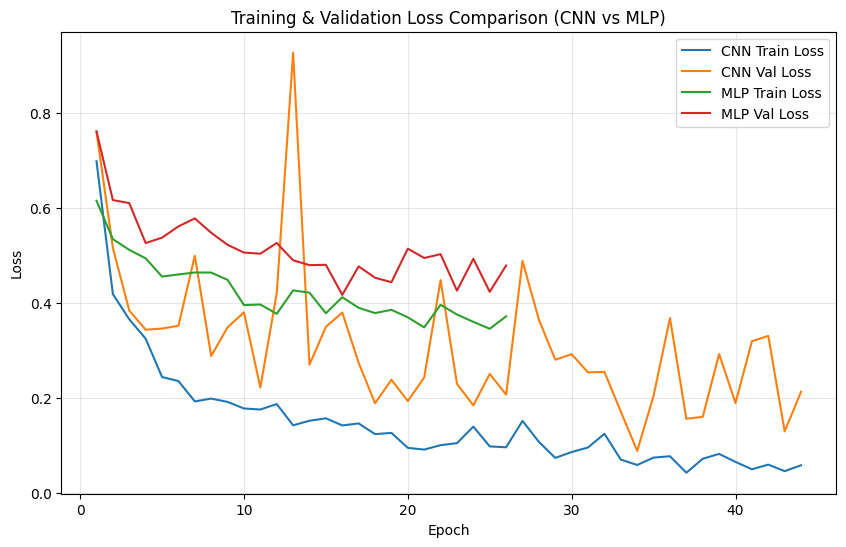

In [26]:
import matplotlib.pyplot as plt

epochs_cnn = range(1, len(cnn_train_losses) + 1)
epochs_mlp = range(1, len(mlp_train_losses) + 1)

plt.figure(figsize=(10, 6))

plt.plot(epochs_cnn, cnn_train_losses, label='CNN Train Loss')
plt.plot(epochs_cnn, cnn_val_losses, label='CNN Val Loss')

plt.plot(epochs_mlp, mlp_train_losses, label='MLP Train Loss')
plt.plot(epochs_mlp, mlp_val_losses, label='MLP Val Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Comparison (CNN vs MLP)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

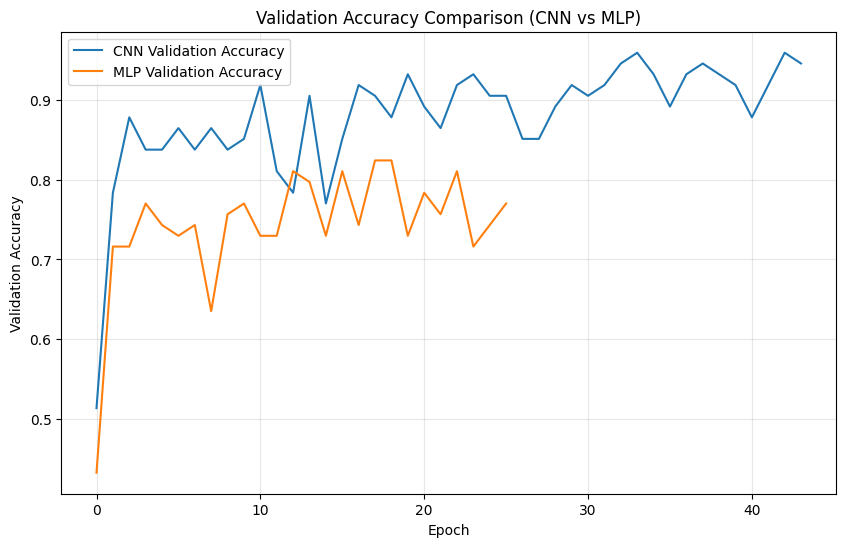

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(cnn_val_accs, label='CNN Validation Accuracy')
plt.plot(mlp_val_accs, label='MLP Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison (CNN vs MLP)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [28]:
import torch
import numpy as np

def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = torch.sigmoid(model(images))
            preds = (outputs > 0.5).int().cpu().numpy()

            all_preds.extend(preds.flatten())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

In [29]:
cnn_true, cnn_pred = get_predictions(model, val_loader)

mlp_true, mlp_pred = get_predictions(mlp_model, val_loader)

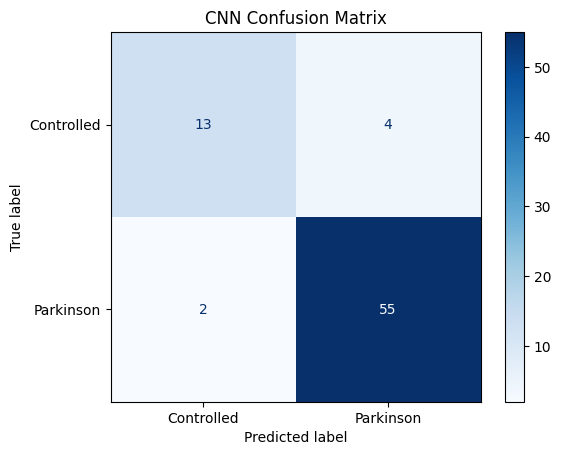

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_cnn = confusion_matrix(cnn_true, cnn_pred)

disp_cnn = ConfusionMatrixDisplay(
    confusion_matrix=cm_cnn,
    display_labels=["Controlled", "Parkinson"]
)

disp_cnn.plot(cmap='Blues')
plt.title("CNN Confusion Matrix")
plt.show()

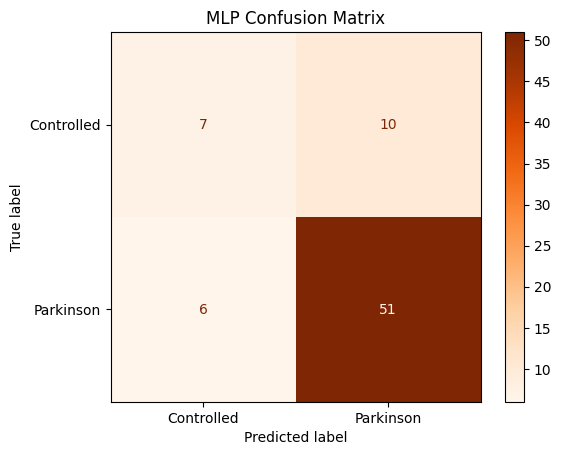

In [31]:
cm_mlp = confusion_matrix(mlp_true, mlp_pred)

disp_mlp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=["Controlled", "Parkinson"]
)

disp_mlp.plot(cmap='Oranges')
plt.title("MLP Confusion Matrix")
plt.show()

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def print_metrics(name, y_true, y_pred):
    print(f"\n{name} Metrics:")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_true, y_pred):.4f}")

print_metrics("CNN", cnn_true, cnn_pred)
print_metrics("MLP", mlp_true, mlp_pred)


CNN Metrics:
Accuracy : 0.9189
Precision: 0.9322
Recall   : 0.9649
F1-score : 0.9483

MLP Metrics:
Accuracy : 0.7838
Precision: 0.8361
Recall   : 0.8947
F1-score : 0.8644


In [33]:
torch.save(model, "cnn_full_model.pth")
torch.save(mlp_model, "mlp_full_model.pth")

print("models saved to disk")

models saved to disk
